# Artem Ivaniuk, Stat 565 Project
## Extension Notebook: COVID Crash Extrapolation (2018-2020)


This notebook extends the Gidea & Katz (2017) replication framework to a new event regime: the COVID crash period.

We keep the same methodological pipeline from `replication.ipynb` (rolling 4D point clouds, $H_1$ persistence, persistence landscape $L^1/L^2$ norms, and trend diagnostics), but re-estimate over a focused sample from 2018 through 2020 to test extrapolation beyond the original dot-com and Lehman events.


#### Environment Setup

In [12]:
import warnings
warnings.filterwarnings("ignore")

from dataclasses import dataclass
from typing import Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ripser import ripser
from scipy.stats import kendalltau

import yfinance as yf

sns.set_theme(style="whitegrid")

In [13]:
TICKERS = {
    "SP500": "^GSPC",
    "DJIA": "^DJI",
    "NASDAQ": "^IXIC",
    "RUSSELL2000": "^RUT",
    "VIX": "^VIX",
}

START_DATE = "2016-12-08"
END_DATE = "2021-01-01"  # end is exclusive in yfinance

WINDOWS = [50, 100]
ROLLING_STATS_WINDOW = 500
PRE_CRASH_DAYS = 250

CRASH_DATES = {
    "COVID": pd.Timestamp("2020-03-16"),
}

#### Data Preprocessing

In [14]:
def download_adjusted_close(tickers: Dict[str, str], start: str, end: str) -> pd.DataFrame:
    raw = yf.download(
        list(tickers.values()),
        start=start,
        end=end,
        auto_adjust=False,
        progress=False,
        group_by="column",
    )

    # yfinance returns MultiIndex columns for multiple symbols
    if isinstance(raw.columns, pd.MultiIndex):
        adj = raw["Adj Close"].copy()
    else:
        adj = raw[["Adj Close"]].rename(columns={"Adj Close": list(tickers.values())[0]})

    inv = {v: k for k, v in tickers.items()}
    adj = adj.rename(columns=inv).sort_index()
    return adj


def compute_log_returns(prices: pd.DataFrame) -> pd.DataFrame:
    # Forward daily log-return: ln(P_t / P_{t-1})
    return np.log(prices / prices.shift(1)).dropna()


prices = download_adjusted_close(TICKERS, START_DATE, END_DATE)
returns = compute_log_returns(prices[["SP500", "DJIA", "NASDAQ", "RUSSELL2000"]])
vix = prices[["VIX"]].reindex(returns.index).dropna()

print("Prices shape:", prices.shape)
print("Returns shape:", returns.shape)
print("Returns period:", returns.index.min().date(), "->", returns.index.max().date())

Prices shape: (1023, 5)
Returns shape: (1022, 4)
Returns period: 2016-12-09 -> 2020-12-31


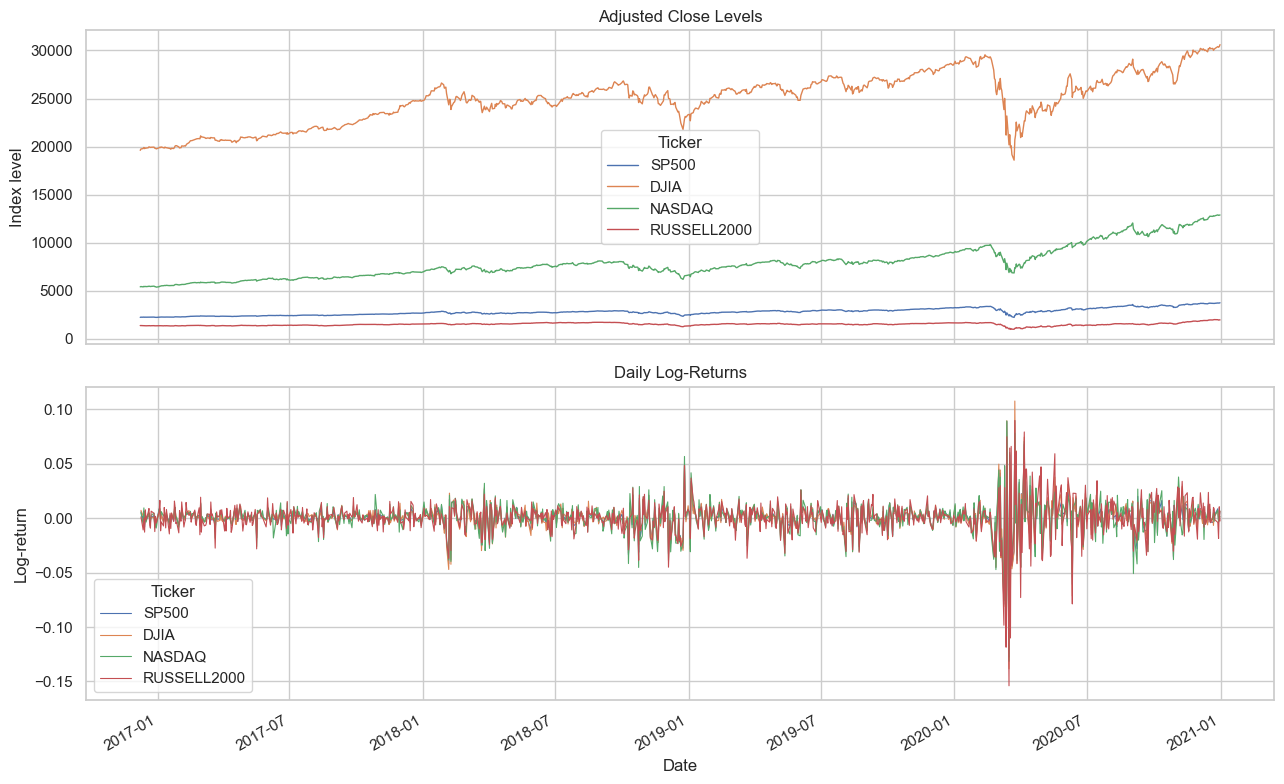

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
prices[["SP500", "DJIA", "NASDAQ", "RUSSELL2000"]].plot(ax=axes[0], linewidth=1)
axes[0].set_title("Adjusted Close Levels")
axes[0].set_ylabel("Index level")

returns.plot(ax=axes[1], linewidth=0.8)
axes[1].set_title("Daily Log-Returns")
axes[1].set_ylabel("Log-return")
plt.tight_layout()

Persistence Landscape Norm Approximation

#### TDA Utility Functions

Convert each windowed point cloud into an `H1` persistence diagram and approximate persistence-landscape norms numerically

In [16]:
def _tent_values(t: np.ndarray, b: float, d: float) -> np.ndarray:
    return np.maximum(0.0, np.minimum(t - b, d - t))


def landscape_lp_norm_from_diagram(diagram: np.ndarray, p: int = 1, grid_size: int = 256) -> float:
    if diagram.size == 0:
        return 0.0

    finite_mask = np.isfinite(diagram).all(axis=1)
    dgm = diagram[finite_mask]
    if dgm.size == 0:
        return 0.0

    births = dgm[:, 0]
    deaths = dgm[:, 1]

    tmin = float(np.min(births))
    tmax = float(np.max(deaths))
    if tmax <= tmin:
        return 0.0

    t = np.linspace(tmin, tmax, grid_size)
    vals = np.vstack([_tent_values(t, b, d) for b, d in dgm])

    vals_sorted = np.sort(vals, axis=0)[::-1]
    if p == 1:
        total = np.trapz(np.sum(vals_sorted, axis=0), t)
        return float(total)

    if p == 2:
        total = np.trapz(np.sum(vals_sorted ** 2, axis=0), t)
        return float(np.sqrt(total))

    total = np.trapz(np.sum(vals_sorted ** p, axis=0), t)
    return float(total ** (1.0 / p))


def h1_diagram_from_point_cloud(X: np.ndarray) -> np.ndarray:
    out = ripser(X, maxdim=1)
    return out["dgms"][1]


def rolling_landscape_norms(data: pd.DataFrame, window: int, grid_size: int = 256) -> pd.DataFrame:
    rows = []
    idx = []
    arr = data.values

    for i in range(len(data) - window + 1):
        X = arr[i : i + window, :]
        dgm1 = h1_diagram_from_point_cloud(X)
        l1 = landscape_lp_norm_from_diagram(dgm1, p=1, grid_size=grid_size)
        l2 = landscape_lp_norm_from_diagram(dgm1, p=2, grid_size=grid_size)
        rows.append((l1, l2))
        idx.append(data.index[i + window - 1])

    return pd.DataFrame(rows, index=pd.DatetimeIndex(idx), columns=["L1", "L2"])

#### Rolling TDA Computation

Apply the sliding-window procedure for each window length and compute `L1`/`L2` norms at every date

In [17]:
norms_by_window = {}
for w in WINDOWS:
    print(f"Computing norms for window={w}...")
    norms_by_window[w] = rolling_landscape_norms(returns, window=w, grid_size=256)

norms_by_window[50].head()

Computing norms for window=50...
Computing norms for window=100...


,L1,L2
2017-02-22,1.806919e-07,0.000005
2017-02-23,4.019675e-07,0.000009
2017-02-24,4.393392e-07,0.000010
2017-02-27,2.285319e-07,0.000006
2017-02-28,2.285319e-07,0.000006


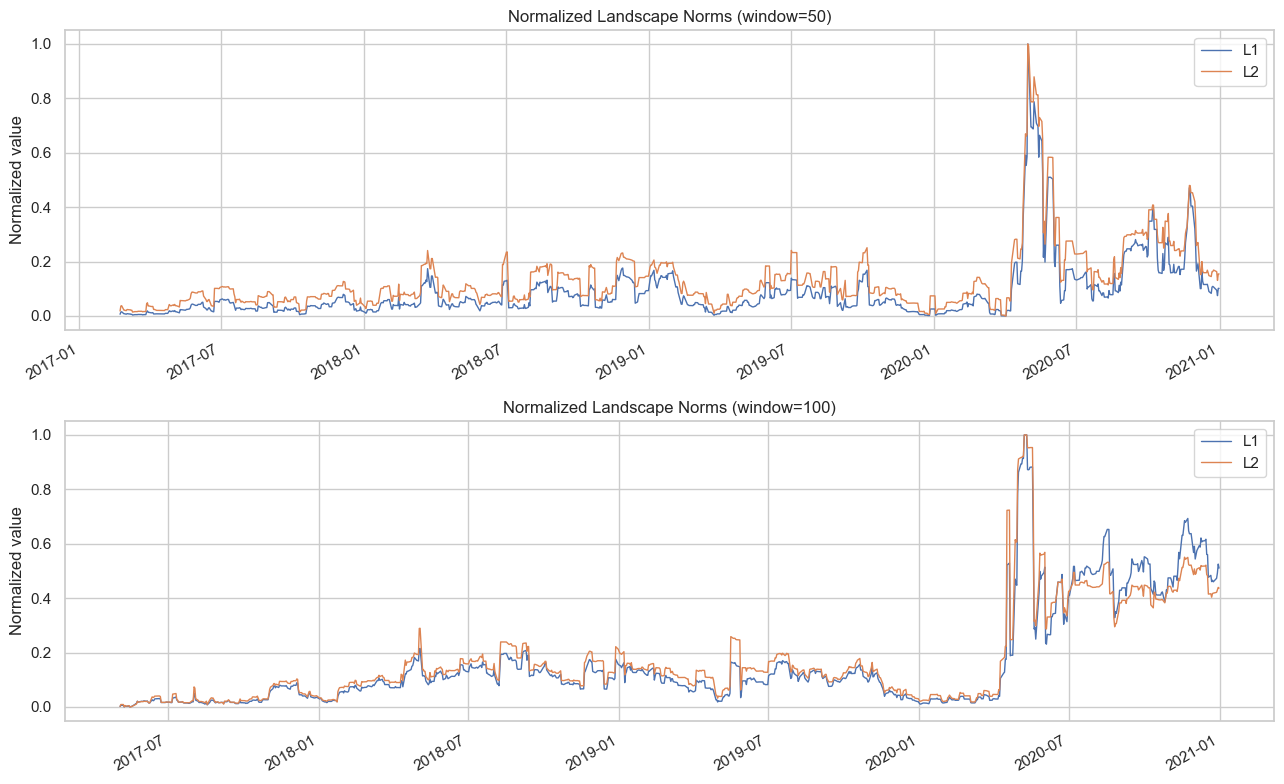

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)
for ax, w in zip(axes, WINDOWS):
    df = norms_by_window[w]
    scaled = (df - df.min()) / (df.max() - df.min())
    scaled[["L1", "L2"]].plot(ax=ax, linewidth=1)
    ax.set_title(f"Normalized Landscape Norms (window={w})")
    ax.set_ylabel("Normalized value")
plt.tight_layout()

#### Event-Centered Comparison Plots

Plot normalized S&P 500, TDA norm, and VIX --> assess whether topological signals show stress buildup before major market breaks

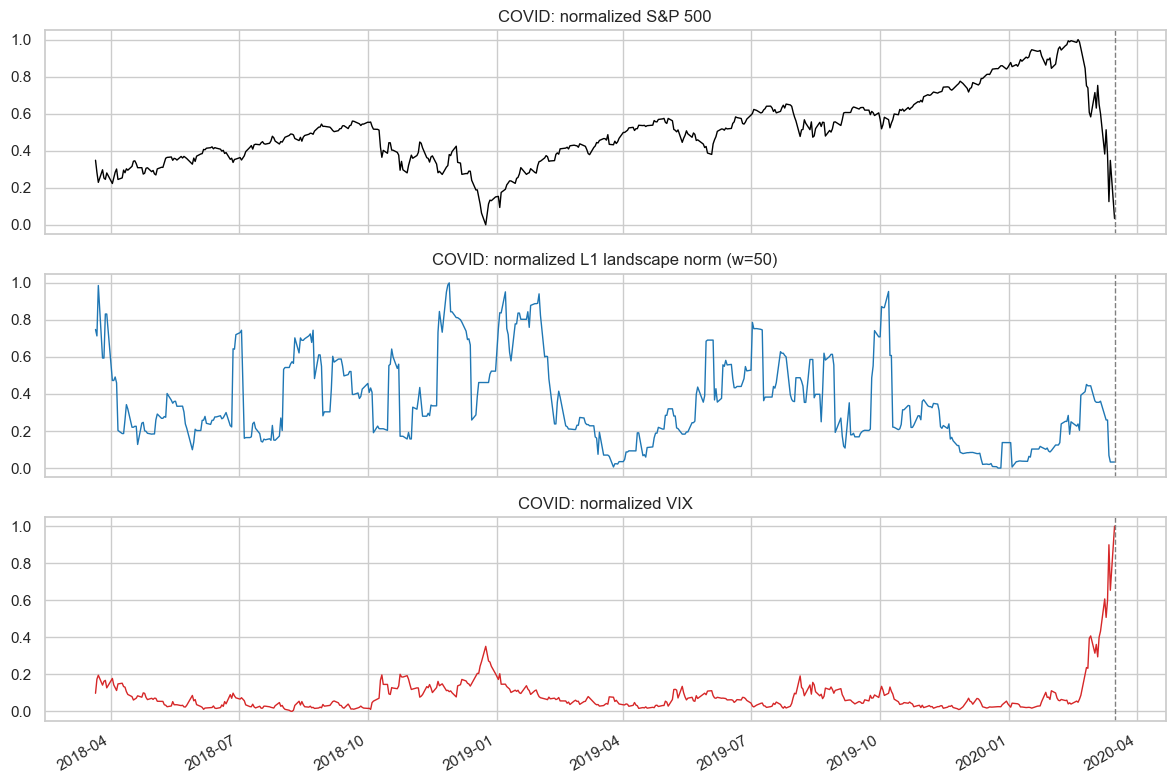

In [19]:
def normalize(s: pd.Series) -> pd.Series:
    return (s - s.min()) / (s.max() - s.min())


def pre_crash_slice(series: pd.Series, crash_date: pd.Timestamp, n_days: int = 500) -> pd.Series:
    series = series.sort_index()
    subset = series.loc[:crash_date]
    return subset.iloc[-n_days:]


norm50 = norms_by_window[50]["L1"].copy()
spx = prices["SP500"].reindex(norm50.index).ffill()
vix_s = vix["VIX"].reindex(norm50.index).ffill()

for label, date in CRASH_DATES.items():
    s_spx = normalize(pre_crash_slice(spx, date, 500))
    s_l1 = normalize(pre_crash_slice(norm50, date, 500))
    s_vix = normalize(pre_crash_slice(vix_s, date, 500))

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    s_spx.plot(ax=axes[0], color="black", linewidth=1)
    axes[0].set_title(f"{label}: normalized S&P 500")

    s_l1.plot(ax=axes[1], color="tab:blue", linewidth=1)
    axes[1].set_title(f"{label}: normalized L1 landscape norm (w=50)")

    s_vix.plot(ax=axes[2], color="tab:red", linewidth=1)
    axes[2].set_title(f"{label}: normalized VIX")

    for ax in axes:
        ax.axvline(date, color="gray", linestyle="--", linewidth=1)
    plt.tight_layout()


#### Early-Warning Statistics and Trend Tests

Compute rolling variance and low-frequency spectral power of the `L1` norm series. Then run Kendall trend tests over the pre-crash window to quantify whether these indicators rise before each event

In [20]:
def rolling_low_freq_power(series: pd.Series, window: int = 500, low_bins: int = 5) -> pd.Series:
    vals = series.values.astype(float)
    out = np.full_like(vals, np.nan, dtype=float)
    for i in range(window - 1, len(vals)):
        x = vals[i - window + 1 : i + 1]
        x = x - np.nanmean(x)
        f = np.fft.rfft(np.nan_to_num(x))
        psd = np.abs(f) ** 2
        out[i] = np.nanmean(psd[1 : 1 + low_bins])
    return pd.Series(out, index=series.index)


def rolling_variance(series: pd.Series, window: int = 500) -> pd.Series:
    return series.rolling(window).var()


def trend_test_pre_crash(series: pd.Series, crash_date: pd.Timestamp, n: int = 250) -> Tuple[float, float]:
    s = series.dropna().loc[:crash_date].iloc[-n:]
    if len(s) < 10:
        return np.nan, np.nan
    x = np.arange(len(s))
    tau, p = kendalltau(x, s.values)
    return float(tau), float(p)


l1_50 = norms_by_window[50]["L1"]
var_l1 = rolling_variance(l1_50, window=ROLLING_STATS_WINDOW)
spec_l1 = rolling_low_freq_power(l1_50, window=ROLLING_STATS_WINDOW, low_bins=5)

for label, date in CRASH_DATES.items():
    tau_var, p_var = trend_test_pre_crash(var_l1, date, n=PRE_CRASH_DAYS)
    tau_spec, p_spec = trend_test_pre_crash(spec_l1, date, n=PRE_CRASH_DAYS)
    print(f"{label} | Variance trend: tau={tau_var:.3f}, p={p_var:.3g}")
    print(f"{label} | Low-freq PSD trend: tau={tau_spec:.3f}, p={p_spec:.3g}")


COVID | Variance trend: tau=0.618, p=5.67e-48
COVID | Low-freq PSD trend: tau=-0.005, p=0.903


#### Save Extension Outputs


In [21]:
out_dir = "results_extension_covid"
import os
os.makedirs(out_dir, exist_ok=True)

returns.to_csv(f"{out_dir}/returns_4indices.csv")
vix.to_csv(f"{out_dir}/vix.csv")

for w, df in norms_by_window.items():
    df.to_csv(f"{out_dir}/landscape_norms_w{w}.csv")

print("Saved outputs to:", out_dir)

Saved outputs to: results_extension_covid


#### COVID Extension Interpretation
Use the printed Kendall trend statistics and the event-centered plots above to evaluate extrapolation:
- If variance and low-frequency PSD trends are both positive/significant in the 250-day pre-COVID window, the original early-warning story extrapolates well.
- If trends are weak, mixed, or inverted, this supports the heterogeneity caveat from the replication/final presentation (signal behavior can depend on crash type).
- Compare the normalized $L_1$ path to VIX: stronger topological fore-shocks before the event support complementary value beyond volatility alone.


In [22]:
# Compact table of COVID pre-crash trend diagnostics
rows = []
for label, date in CRASH_DATES.items():
    tau_var, p_var = trend_test_pre_crash(var_l1, date, n=PRE_CRASH_DAYS)
    tau_spec, p_spec = trend_test_pre_crash(spec_l1, date, n=PRE_CRASH_DAYS)
    rows.append({
        "event": label,
        "date": date.date(),
        "tau_variance": tau_var,
        "p_variance": p_var,
        "tau_low_freq_psd": tau_spec,
        "p_low_freq_psd": p_spec,
    })
pd.DataFrame(rows)


,event,date,tau_variance,p_variance,tau_low_freq_psd,p_low_freq_psd
0,COVID,2020-03-16,0.617863,5.671830e-48,-0.005173,0.903035
